In [1]:
import matplotlib.pyplot as plt
from lib.echorepo import EchoRepo

echo = EchoRepo()

print("ECHOREPO URL:", echo.base_url)
print("Connection:", echo.ping())

ECHOREPO URL: http://echorepo-lite:8000
Connection: {'ok': True}


In [2]:
samples = echo.samples()
parameters = echo.parameters()
images = echo.images()
biodiversity = echo.biodiversity()

print(f"Samples:       {len(samples):,}")
print(f"Parameters:    {len(parameters):,}")
print(f"Images:        {len(images):,}")
print(f"Biodiversity:  {len(biodiversity):,}")

Samples:       7,726
Parameters:    23,308
Images:        19,557
Biodiversity:  23,129


In [3]:
print("Unique samples:", samples["sample_id"].nunique())

print(
    "Parameter sample IDs missing from samples:",
    len(set(parameters["sample_id"]) - set(samples["sample_id"])),
)

print(
    "Biodiversity sample IDs missing from samples:",
    len(set(biodiversity["sample_id"]) - set(samples["sample_id"])),
)

Unique samples: 7726
Parameter sample IDs missing from samples: 0
Biodiversity sample IDs missing from samples: 0


In [4]:
samples["country_code"].value_counts().head(20)

country_code
IT    1121
RO    1068
ES     940
PT     848
PL     716
DE     651
FI     614
GR     564
GB     332
FR     155
AT     134
EE      89
LU      83
CH      74
LV      68
BG      63
BE      60
SI      53
NL      22
SE      17
Name: count, dtype: int64

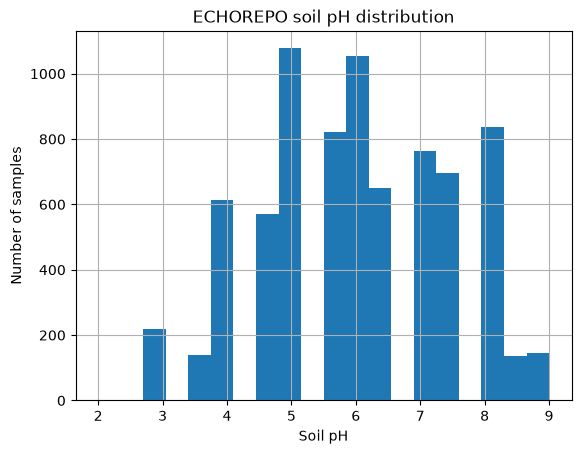

In [5]:
samples["ph"].dropna().hist(bins=20)

plt.xlabel("Soil pH")
plt.ylabel("Number of samples")
plt.title("ECHOREPO soil pH distribution")
plt.show()

In [6]:
(
    samples.groupby("country_code")["ph"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
    .head(20)
)

,count,mean,median
country_code,,,
IT,1120,6.544643,7.00
RO,1068,5.824906,5.50
ES,940,6.493085,6.75
PT,848,5.655660,5.50
PL,716,5.599860,5.50
DE,649,6.131741,6.00
FI,614,4.973127,5.00
GR,564,6.789007,7.00
GB,332,5.490964,5.50


In [7]:
(
    biodiversity.groupby(["marker", "scientific_name"])["read_count"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
)

marker  scientific_name         
ITS     Ascomycota                  34179480.0
16S     Pseudomonadota              11303073.0
ITS     Basidiomycota                7400476.0
16S     Acidobacteriota              6066930.0
        Actinomycetota               5689017.0
ITS     Fungi_phy_Incertae_sedis     2434133.0
16S     Planctomycetota              1836646.0
        Chloroflexota                1799753.0
ITS     Mortierellomycota            1488351.0
16S     Bacillota                    1314738.0
        Myxococcota                  1306793.0
        Bacteroidota                 1238551.0
        Gemmatimonadota              1189733.0
        Verrucomicrobiota            1120670.0
ITS     Rozellomycota                 566835.0
        Mucoromycota                  417566.0
        Glomeromycota                 407835.0
        Chytridiomycota               344739.0
16S     Methylomirabilota             322928.0
        Nitrospirota                  286797.0
        Thermodesulfobacter

In [8]:
country_stats = (
    samples.groupby("country_code")
    .agg(
        samples=("sample_id", "count"),
        mean_ph=("ph", "mean"),
        mean_soc=("organic_carbon_pct", "mean"),
    )
    .reset_index()
)

country_stats.to_csv(
    "exports/country_statistics.csv",
    index=False,
)